# Welcome to the tutorial on BMS symmetries and black hole perturbations!

Today we'll be covering, from a relatively zoomed out perspective:
* what the BMS symmetries are,
* how one can use them to write the sources of the gravitational wave strain in terms of BMS charges and fluxes,
* how to fit quasi-normal modes to NR waveforms,
* how to fit quasi-normal modes to LVK observations.
  
So, without further ado, let's get started!

If you're working with `uv` or with `conda` and have the corresponding environment activated, then you should have the packages required for this notebook installed.

### Let's download some data!

The files we're downloading are:
* the strain waveform
* and the five Weyl scalar files $\Psi_{0-4}$ (which should really be thought of as tensor components, not scalars

output by a Cauchy-characteristic evolution (CCE) code. Normally the Weyl scalars aren't included in the SXS catalog since CCE 
is a relatively new development, so we'll need to download them from the SXS Collaboration's mini-catalog. In the future though,
the SXS catalog will indeed contain such files as they are very useful for gravitational wave research.

The files we'll download correspond to a $q=1$, non-spinning system, but there are many other systems that you can examine.

In [1]:
from utils_downloads import download_extcce_simulation

Choose any of the alt names from [this SXS mini-catalog](https://data.black-holes.org/waveforms/extcce_catalog.html), but, again, we'll work with `q1_nospin` for now.

In [2]:
simulation = "q1_nospin" 
download_extcce_simulation(simulation);

Exists:  ./q1_nospin/r4Psi1OverM2_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/r4Psi1OverM2_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/r2Psi3_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/r5Psi0OverM3_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/r5Psi0OverM3_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/metadata.json
Exists:  ./q1_nospin/rhOverM_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/rhOverM_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/r2Psi3_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/rMPsi4_BondiCce_R0292_CoM.h5
Exists:  ./q1_nospin/rMPsi4_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/r3Psi2OverM_BondiCce_R0292_CoM.json
Exists:  ./q1_nospin/r3Psi2OverM_BondiCce_R0292_CoM.h5


### Loading an ABD object

The strain and the Weyl scalars downloaded above provide all of the information needed to construct the asymptotic metric.

We can load all of them into a single object, known as a `AsymptoticBondiData` object, using the `scri` package via:

In [3]:
import os, h5py, scri
from scri.asymptotic_bondi_data.map_to_superrest_frame import MT_to_WM, WM_to_MT

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('paper.mplstyle')

# Colorblind friendly from Nichols
colors = [
    "#000000",
    "#0072B2",
    "#009E73",
    "#E69F00",
    "#CC79A7",
    "#56B4E9",
    "#F0E442",
    "#D55E00",
]
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=colors)

# widths for PRD/PRL
onecol_w_in = 3.4
twocol_w_in = 7.0625

In [4]:
path_to_simulation = f"{simulation}"

input_radius = [x.split("_R")[1][:4] for x in os.listdir(path_to_simulation) if "rhOverM" in x][0]

abd = scri.SpEC.file_io.create_abd_from_h5(
    h=f"{path_to_simulation}/rhOverM_BondiCce_R{input_radius}_CoM.h5",
    Psi4=f"{path_to_simulation}/rMPsi4_BondiCce_R{input_radius}_CoM.h5",
    Psi3=f"{path_to_simulation}/r2Psi3_BondiCce_R{input_radius}_CoM.h5",
    Psi2=f"{path_to_simulation}/r3Psi2OverM_BondiCce_R{input_radius}_CoM.h5",
    Psi1=f"{path_to_simulation}/r4Psi1OverM2_BondiCce_R{input_radius}_CoM.h5",
    Psi0=f"{path_to_simulation}/r5Psi0OverM3_BondiCce_R{input_radius}_CoM.h5",
    file_format="RPXMB",
)
abd.t -= abd.t[np.argmax(MT_to_WM(2.0*abd.sigma.bar.dot).norm())]

dt = 1.0
abd = abd.interpolate(np.arange(abd.t[0], abd.t[-1] + dt, dt))

In [5]:
from utils_scri import strain_as_charges_and_fluxes

In [6]:
h, h_m, h_E, h_N, h_J = strain_as_charges_and_fluxes(abd)

/Users/keefemitman/Desktop/Research/ResearchTutorials/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/keefemitman/Desktop/Research/ResearchTutorials/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


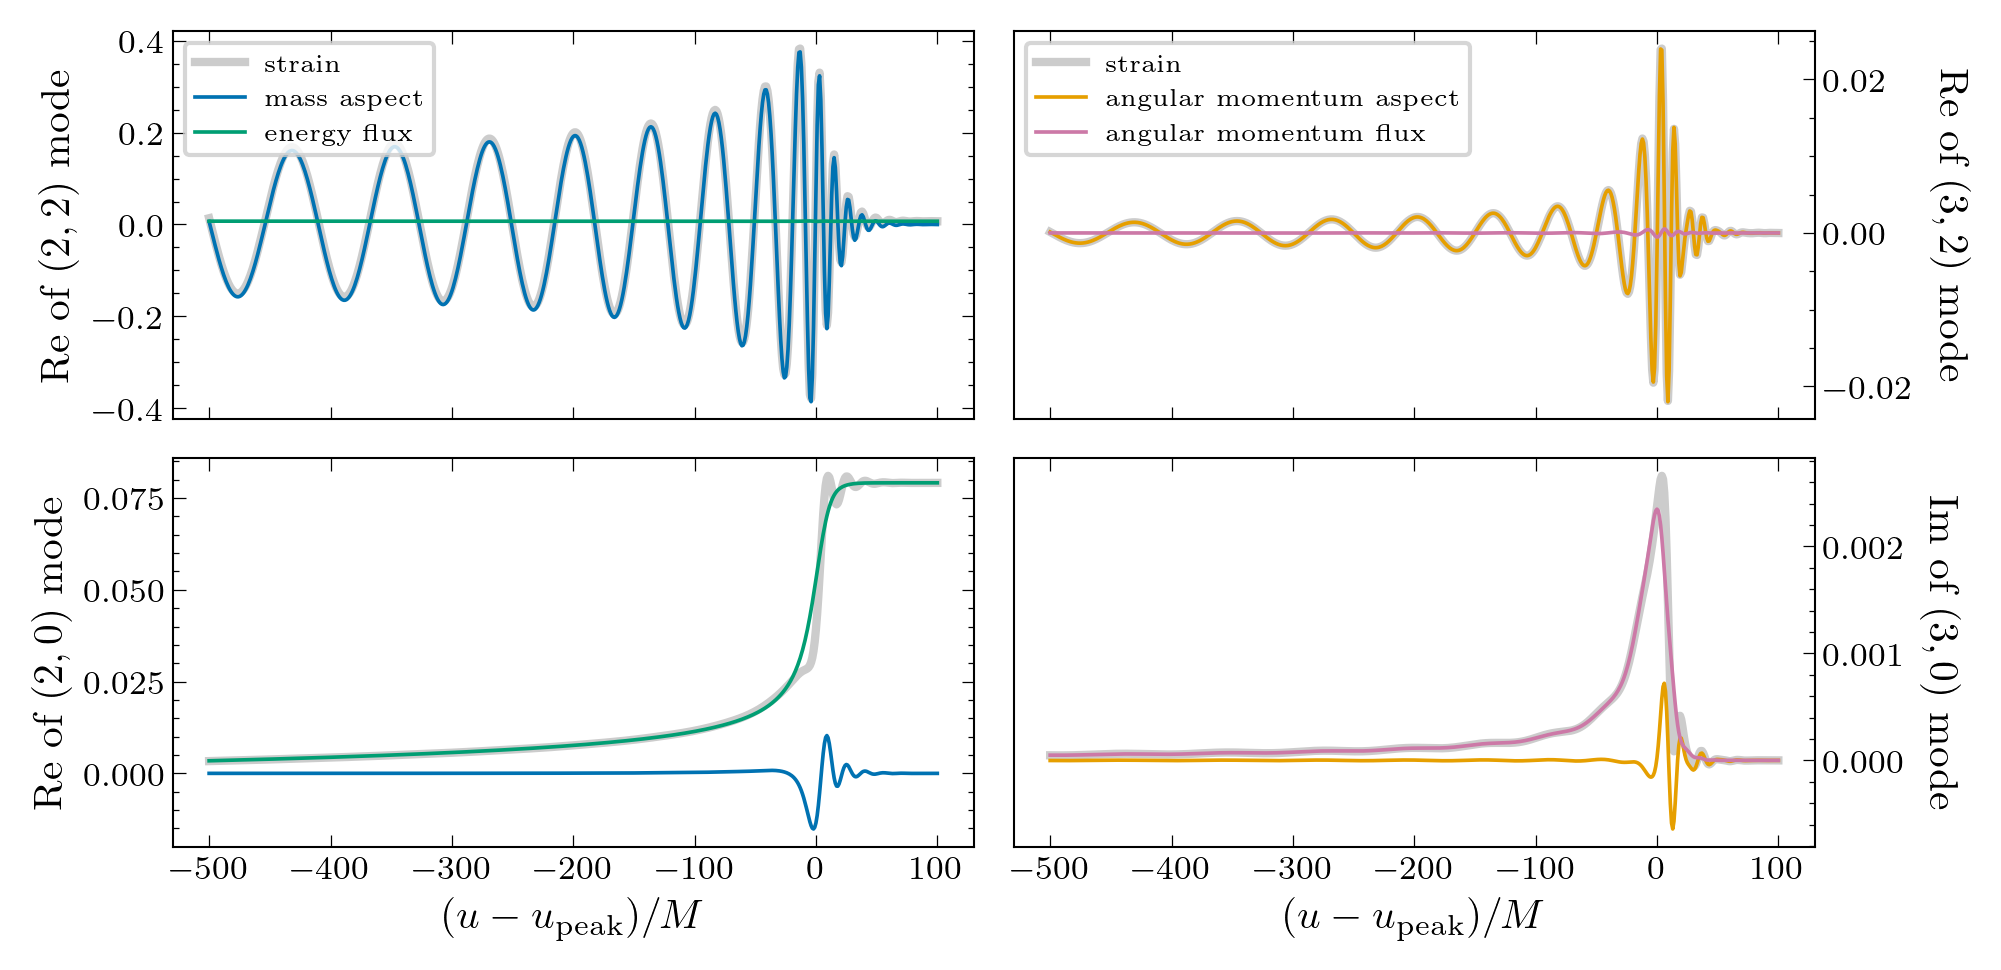

In [7]:
fig, axis = plt.subplots(2, 2, figsize=(twocol_w_in, twocol_w_in * 0.5), sharex=True)
plt.subplots_adjust(hspace=0.1, wspace=0.05)

idx1 = np.argmin(abs(h.t - -500))
idx2 = np.argmin(abs(h.t - 100)) + 1

L = 2; M = 2;
axis[0][0].plot(h.t[idx1:idx2], h.data[idx1:idx2,h.index(L,M)], lw=2, alpha=0.2, label='strain', color=colors[0])
axis[0][0].plot(h.t[idx1:idx2], h_m.data[idx1:idx2,h.index(L,M)], label='mass aspect', color=colors[1], lw=0.88)
axis[0][0].plot(h.t[idx1:idx2], h_E.data[idx1:idx2,h.index(L,M)], label='energy flux', color=colors[2], lw=0.88)
axis[0][0].legend(frameon=True, loc='upper left')

L = 3; M = 2;
axis[0][1].plot(h.t[idx1:idx2], h.data[idx1:idx2,h.index(L,M)], lw=2, alpha=0.2, label='strain', color=colors[0])
axis[0][1].plot(h.t[idx1:idx2], h_N.data[idx1:idx2,h.index(L,M)], label='angular momentum aspect', color=colors[3], lw=0.88)
axis[0][1].plot(h.t[idx1:idx2], h_J.data[idx1:idx2,h.index(L,M)], label='angular momentum flux', color=colors[4], lw=0.88)
axis[0][1].legend(frameon=True, loc='upper left')

axis[0][1].yaxis.set_label_position("right")
axis[0][1].yaxis.tick_right()

L = 2; M = 0;
axis[1][0].plot(h.t[idx1:idx2], h.data[idx1:idx2,h.index(L, M)], lw=2, alpha=0.2, label='strain', color=colors[0])
axis[1][0].plot(h.t[idx1:idx2], h_m.data[idx1:idx2,h.index(L,M)], label='mass aspect', color=colors[1], lw=0.88)
axis[1][0].plot(h.t[idx1:idx2], h_E.data[idx1:idx2,h.index(L,M)], label='energy flux', color=colors[2], lw=0.88)

L = 3; M = 0;
axis[1][1].plot(h.t[idx1:idx2], h.data[idx1:idx2,h.index(L,M)].imag, lw=2, alpha=0.2, label='strain', color=colors[0])
axis[1][1].plot(h.t[idx1:idx2], h_N.data[idx1:idx2,h.index(L,M)].imag, label='angular momentum aspect', color=colors[3], lw=0.88)
axis[1][1].plot(h.t[idx1:idx2], h_J.data[idx1:idx2,h.index(L,M)].imag, label='angular momentum flux', color=colors[4], lw=0.88)

axis[1][1].yaxis.set_label_position("right")
axis[1][1].yaxis.tick_right()

axis[1][0].set_xlabel(r'$(u-u_{\mathrm{peak}})/M$')
axis[1][1].set_xlabel(r'$(u-u_{\mathrm{peak}})/M$')
axis[0][0].set_ylabel(r'Re of $(2,2)$ mode')
axis[0][1].set_ylabel(r'Re of $(3,2)$ mode', rotation=270, labelpad=14)
axis[1][0].set_ylabel(r'Re of $(2,0)$ mode')
axis[1][1].set_ylabel(r'Im of $(3,0)$ mode', rotation=270, labelpad=14);